# Telco Customer Churn Data Check

This notebook reviews the raw Telco churn workbook and builds a simple baseline model. The goal is to confirm the file structure, inspect the main feature groups, document the `Total Charges` data issue, prepare a modeling table, and evaluate a first logistic regression benchmark.

In [1]:
from pathlib import Path
import pandas as pd

In [2]:
file_path = Path("../data/raw/Telco_customer_churn.xlsx")

In [3]:
file_path.exists()

True

In [4]:
xls = pd.ExcelFile(file_path)
xls.sheet_names

['Telco_Churn']

In [5]:
df = pd.read_excel(file_path, sheet_name="Telco_Churn")
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [6]:
df.shape

(7043, 33)

In [7]:
df.columns.tolist()

['CustomerID',
 'Count',
 'Country',
 'State',
 'City',
 'Zip Code',
 'Lat Long',
 'Latitude',
 'Longitude',
 'Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Tenure Months',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Monthly Charges',
 'Total Charges',
 'Churn Label',
 'Churn Value',
 'Churn Score',
 'CLTV',
 'Churn Reason']

In [8]:
df.sample(10)

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
1844,0886-QGENL,1,United States,California,San Diego,92104,"32.741499, -117.127409",32.741499,-117.127409,Female,...,Month-to-month,Yes,Electronic check,101.25,2754.45,Yes,1,77,4853,Attitude of service provider
783,9685-WKZGT,1,United States,California,Carmichael,95608,"38.626128, -121.328011",38.626128,-121.328011,Male,...,Month-to-month,Yes,Electronic check,74.95,1036.75,Yes,1,70,2075,Extra data charges
6475,7268-WNTCP,1,United States,California,Blocksburg,95514,"40.309088, -123.668201",40.309088,-123.668201,Male,...,Two year,No,Bank transfer (automatic),20.45,1297.35,No,0,21,5746,NaN
4696,1080-BWSYE,1,United States,California,Irvine,92618,"33.667145, -117.732135",33.667145,-117.732135,Male,...,Two year,No,Credit card (automatic),25.65,1740.8,No,0,36,6469,NaN
3877,7274-CGTOD,1,United States,California,San Geronimo,94963,"38.00474, -122.663717",38.004740,-122.663717,Male,...,Two year,Yes,Bank transfer (automatic),43.70,2618.3,No,0,58,5254,NaN
5373,6116-RFVHN,1,United States,California,Roseville,95747,"38.784329, -121.373245",38.784329,-121.373245,Female,...,Month-to-month,Yes,Electronic check,100.45,3414.65,No,0,42,3744,NaN
4477,1703-MGIAB,1,United States,California,Van Nuys,91406,"34.195685, -118.490752",34.195685,-118.490752,Female,...,Month-to-month,Yes,Mailed check,69.00,1108,No,0,22,4439,NaN
1989,2749-CTKAJ,1,United States,California,Long Beach,90813,"33.781086, -118.199049",33.781086,-118.199049,Male,...,One year,No,Mailed check,20.15,419.9,No,0,72,2173,NaN
6812,1173-XZPYF,1,United States,California,Torrance,90501,"33.833699, -118.314387",33.833699,-118.314387,Female,...,Month-to-month,Yes,Electronic check,89.20,990.3,No,0,32,3734,NaN
210,6982-SSHFK,1,United States,California,Fresno,93703,"36.768774, -119.762633",36.768774,-119.762633,Male,...,Month-to-month,No,Mailed check,44.40,44.4,Yes,1,89,3522,Competitor offered higher download speeds


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

## Feature Spot Checks

Before cleaning or modeling, the next few samples group related columns so the schema is easier to read in business terms.

In [10]:
df[["Tenure Months", "Monthly Charges", "Contract", "Total Charges", "Payment Method", "Paperless Billing"]].sample(10)

,Tenure Months,Monthly Charges,Contract,Total Charges,Payment Method,Paperless Billing
5188,60,97.95,One year,5867,Electronic check,Yes
1883,12,19.80,One year,202.25,Bank transfer (automatic),No
4725,26,82.00,One year,2083.1,Credit card (automatic),Yes
3570,43,104.30,One year,4451.85,Credit card (automatic),Yes
3083,60,80.95,Month-to-month,4859.1,Electronic check,Yes
2687,69,24.60,Two year,1678.05,Credit card (automatic),No
5274,65,45.25,Two year,2933.95,Mailed check,No
1786,1,69.20,Month-to-month,69.2,Electronic check,Yes
3477,46,19.95,Two year,862.4,Credit card (automatic),No
5135,30,97.00,One year,3021.3,Bank transfer (automatic),Yes


### Service-Related Features

These columns capture subscription mix and support add-ons, which are common churn drivers in telecom churn datasets.

In [11]:
df[["Phone Service", "Multiple Lines", "Internet Service", "Online Security", "Online Backup", "Device Protection", "Tech Support", "Streaming TV", "Streaming Movies"]].sample(10)

,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies
6987,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes
1403,No,No phone service,DSL,No,No,No,Yes,No,No
6903,Yes,No,DSL,No,No,No,No,No,No
5203,Yes,Yes,Fiber optic,No,Yes,Yes,Yes,Yes,Yes
3732,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,No
5596,Yes,No,DSL,Yes,No,Yes,No,No,No
4368,Yes,No,Fiber optic,No,No,No,No,No,No
3813,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service
1123,Yes,No,DSL,No,Yes,No,No,No,No
6357,Yes,Yes,Fiber optic,Yes,No,Yes,Yes,Yes,Yes


### Household And Demographic Features

These fields describe basic customer context that may help explain retention differences across customer segments.

In [12]:
df[["Gender", "Senior Citizen", "Partner", "Dependents"]].sample(10)

,Gender,Senior Citizen,Partner,Dependents
6992,Female,No,Yes,No
2739,Female,No,No,No
6371,Male,No,No,No
5275,Male,No,Yes,Yes
6612,Female,No,No,No
3513,Male,No,No,No
51,Male,No,No,No
4454,Female,No,Yes,No
1489,Male,No,Yes,No
3678,Female,No,Yes,Yes


## Target Review

This block checks the churn class balance and confirms that the text label `Churn Label` matches the numeric target `Churn Value` exactly.

In [13]:
df["Churn Label"].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [14]:
df["Churn Label"].value_counts(normalize=True)

Churn Label
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [15]:
pd.crosstab(df["Churn Label"], df["Churn Value"])

Churn Value,0,1
Churn Label,,
No,5174,0
Yes,0,1869


## Data Quality Check for `Total Charges`

`Total Charges` is loaded as an object column, so the next checks confirm whether the issue is true missing data or blank strings before coercing it to numeric.

In [16]:
df["Total Charges"].head(10)

0     108.15
1     151.65
2      820.5
3    3046.05
4     5036.3
5     528.35
6      39.65
7      20.15
8    4749.15
9       30.2
Name: Total Charges, dtype: object

In [17]:
df["Total Charges"].isna().sum()

0

In [18]:
(df["Total Charges"] == " ").sum()

11

In [19]:
df[df["Total Charges"] == " "]

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
2234,4472-LVYGI,1,United States,California,San Bernardino,92408,"34.084909, -117.258107",34.084909,-117.258107,Female,...,Two year,Yes,Bank transfer (automatic),52.55,,No,0,36,2578,NaN
2438,3115-CZMZD,1,United States,California,Independence,93526,"36.869584, -118.189241",36.869584,-118.189241,Male,...,Two year,No,Mailed check,20.25,,No,0,68,5504,NaN
2568,5709-LVOEQ,1,United States,California,San Mateo,94401,"37.590421, -122.306467",37.590421,-122.306467,Female,...,Two year,No,Mailed check,80.85,,No,0,45,2048,NaN
2667,4367-NUYAO,1,United States,California,Cupertino,95014,"37.306612, -122.080621",37.306612,-122.080621,Male,...,Two year,No,Mailed check,25.75,,No,0,48,4950,NaN
2856,1371-DWPAZ,1,United States,California,Redcrest,95569,"40.363446, -123.835041",40.363446,-123.835041,Female,...,Two year,No,Credit card (automatic),56.05,,No,0,30,4740,NaN
4331,7644-OMVMY,1,United States,California,Los Angeles,90029,"34.089953, -118.294824",34.089953,-118.294824,Male,...,Two year,No,Mailed check,19.85,,No,0,53,2019,NaN
4687,3213-VVOLG,1,United States,California,Sun City,92585,"33.739412, -117.173334",33.739412,-117.173334,Male,...,Two year,No,Mailed check,25.35,,No,0,49,2299,NaN
5104,2520-SGTTA,1,United States,California,Ben Lomond,95005,"37.078873, -122.090386",37.078873,-122.090386,Female,...,Two year,No,Mailed check,20.00,,No,0,27,3763,NaN
5719,2923-ARZLG,1,United States,California,La Verne,91750,"34.144703, -117.770299",34.144703,-117.770299,Male,...,One year,Yes,Mailed check,19.70,,No,0,69,4890,NaN
6772,4075-WKNIU,1,United States,California,Bell,90201,"33.970343, -118.171368",33.970343,-118.171368,Female,...,Two year,No,Mailed check,73.35,,No,0,44,2342,NaN


In [20]:
df.loc[df["Total Charges"] == " ", "Tenure Months"]

2234    0
2438    0
2568    0
2667    0
2856    0
4331    0
4687    0
5104    0
5719    0
6772    0
6840    0
Name: Tenure Months, dtype: int64

In [21]:
df.loc[df['Total Charges'] == " ", 'Tenure Months'].value_counts()

Tenure Months
0    11
Name: count, dtype: int64

In [22]:
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce") #'coerce' will convert non-numeric values to NaN
# 'ignore' option will leave non-numeric values as they are, which can lead to issues in analysis and modeling
# 'raise' option will raise an error if non-numeric values are encountered, which can help identify and address data quality issues early on

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [24]:
df["Total Charges"].isna().sum()

11

In [25]:
df[["Tenure Months", "Monthly Charges", "Total Charges"]].describe()

,Tenure Months,Monthly Charges,Total Charges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


## Column Audit And Leakage Review

These summaries help separate stable predictors from identifiers, constants, and post-outcome fields that should not be used when training the model.

In [26]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


--- CustomerID ---
CustomerID
3668-QPYBK    1
9169-BSVIN    1
0206-OYVOC    1
6418-HNFED    1
8805-JNRAZ    1
             ..
6797-UCJHZ    1
5016-IBERQ    1
3003-CMDUU    1
5148-HKFIR    1
3186-AJIEK    1
Name: count, Length: 7043, dtype: int64

--- Country ---
Country
United States    7043
Name: count, dtype: int64

--- State ---
State
California    7043
Name: count, dtype: int64

--- City ---
City
Los Angeles       305
San Diego         150
San Jose          112
Sacramento        108
San Francisco     104
                 ... 
Healdsburg          4
Jenner              4
Philo               4
Point Arena         4
Olympic Valley      4
Name: count, Length: 1129, dtype: int64

--- Lat Long ---
Lat Long
33.964131, -118.272783    5
34.152875, -118.486056    5
32.912664, -116.635387    5
32.64164, -116.985026     5
32.607964, -117.059459    5
                         ..
37.4695, -120.672724      4
38.055562, -120.456298    4
38.244806, -120.417301    4
38.264262, -120.515133    4
39.191

In [27]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
numeric_cols.tolist()

['Count',
 'Zip Code',
 'Latitude',
 'Longitude',
 'Tenure Months',
 'Monthly Charges',
 'Total Charges',
 'Churn Value',
 'Churn Score',
 'CLTV']

In [28]:
df["CLTV"].describe()

count    7043.000000
mean     4400.295755
std      1183.057152
min      2003.000000
25%      3469.000000
50%      4527.000000
75%      5380.500000
max      6500.000000
Name: CLTV, dtype: float64

In [29]:
df["Count"].value_counts(dropna=False)

Count
1    7043
Name: count, dtype: int64

In [30]:
df["Zip Code"].nunique()

1652

In [31]:
df["CustomerID"].nunique()

7043

In [32]:
df["Churn Reason"].notna().sum()

1869

In [33]:
df["Churn Label"].value_counts(dropna=False)

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [34]:
pd.crosstab(df["Churn Label"], df["Churn Reason"].notna())

Churn Reason,False,True
Churn Label,,
No,5174,0
Yes,0,1869


In [35]:
df.groupby("Churn Label")["Churn Score"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn Label,,,,,,,,
No,5174.0,50.098183,17.702277,5.0,35.0,50.0,66.0,80.0
Yes,1869.0,82.510433,10.328570,65.0,74.0,82.0,91.0,100.0


In [36]:
df.groupby("Churn Label")["CLTV"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn Label,,,,,,,,
No,5174.0,4490.921337,1167.703198,2003.0,3643.75,4620.0,5434.75,6500.0
Yes,1869.0,4149.414660,1189.370707,2003.0,3101.00,4238.0,5166.00,6484.0


## Build the Modeling Dataset

The next step removes location identifiers, constant fields, and churn-outcome columns, then keeps a cleaner table for the baseline model.

In [37]:
drop_cols = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",
    "Churn Label",
    "Churn Score",
    "CLTV",
    "Churn Reason"
]

keep_for_now = [col for col in df.columns if col not in drop_cols]

keep_for_now

['Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Tenure Months',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Monthly Charges',
 'Total Charges',
 'Churn Value']

In [38]:
model_df = df[keep_for_now].copy()
model_df.shape

(7043, 20)

In [39]:
model_df.isna().sum()

Gender                0
Senior Citizen        0
Partner               0
Dependents            0
Tenure Months         0
Phone Service         0
Multiple Lines        0
Internet Service      0
Online Security       0
Online Backup         0
Device Protection     0
Tech Support          0
Streaming TV          0
Streaming Movies      0
Contract              0
Paperless Billing     0
Payment Method        0
Monthly Charges       0
Total Charges        11
Churn Value           0
dtype: int64

In [40]:
model_df["Total Charges"].isna().mean()

0.001561834445548772

In [41]:
model_df[model_df["Total Charges"].isna()]

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
2234,Female,No,Yes,No,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,0
2438,Male,No,No,No,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,0
2568,Female,No,Yes,No,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,0
2667,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,0
2856,Female,No,Yes,No,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,0
4331,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,0
4687,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,0
5104,Female,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,0
5719,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,0
6772,Female,No,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,0


In [42]:
model_df["Total Charges"] = model_df["Total Charges"].fillna(0)

In [43]:
model_df["Total Charges"].isna().sum()

0

In [44]:
X = model_df.drop(columns=["Churn Value"]) # another way to do this is: X = model_df.loc[:, model_df.columns != "Churn Value"]
y = model_df["Churn Value"]

In [45]:
X.shape, y.shape

((7043, 19), (7043,))

In [46]:
X.dtypes

Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges        float64
dtype: object

In [47]:
X.select_dtypes(include="object").columns.tolist(), X.select_dtypes(exclude="object").columns.tolist()

(['Gender',
  'Senior Citizen',
  'Partner',
  'Dependents',
  'Phone Service',
  'Multiple Lines',
  'Internet Service',
  'Online Security',
  'Online Backup',
  'Device Protection',
  'Tech Support',
  'Streaming TV',
  'Streaming Movies',
  'Contract',
  'Paperless Billing',
  'Payment Method'],
 ['Tenure Months', 'Monthly Charges', 'Total Charges'])

In [48]:
X.select_dtypes(include="object").columns.tolist()

['Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method']

## Train/Test Split And Preprocessing

A stratified split preserves the churn rate in both samples. Categorical features are one-hot encoded, and numeric features are standardized inside a reusable preprocessing step.

In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5634, 19), (1409, 19), (5634,), (1409,))

In [50]:
y_train.value_counts(normalize=True), y_test.value_counts(normalize=True)

(Churn Value
 0    0.734647
 1    0.265353
 Name: proportion, dtype: float64,
 Churn Value
 0    0.734564
 1    0.265436
 Name: proportion, dtype: float64)

In [51]:
categorical_cols = X_train.select_dtypes(include="object").columns.tolist()
numeric_cols = X_train.select_dtypes(exclude="object").columns.tolist()

categorical_cols, numeric_cols

(['Gender',
  'Senior Citizen',
  'Partner',
  'Dependents',
  'Phone Service',
  'Multiple Lines',
  'Internet Service',
  'Online Security',
  'Online Backup',
  'Device Protection',
  'Tech Support',
  'Streaming TV',
  'Streaming Movies',
  'Contract',
  'Paperless Billing',
  'Payment Method'],
 ['Tenure Months', 'Monthly Charges', 'Total Charges'])

In [52]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

In [53]:
preprocessor = ColumnTransformer(
    transformers = [
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), numeric_cols)
    ]
)

## Baseline Logistic Regression

Logistic regression is used here as an interpretable starting point before trying more complex models.

In [54]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)



In [55]:
from sklearn.pipeline import Pipeline

clf = Pipeline(
    steps = [
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

In [56]:
clf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender', 'Senior Citizen',
                                                   'Partner', 'Dependents',
                                                   'Phone Service',
                                                   'Multiple Lines',
                                                   'Internet Service',
                                                   'Online Security',
                                                   'Online Backup',
                                                   'Device Protection',
                                                   'Tech Support',
                                                   'Streaming TV',
                                                   'Streaming Movies',
                                                   'Contract',
                                                   'Paperless Billing',
                                                   'Payment Method']),
                                                 ('num', StandardScaler(),
                                                  ['Tenure Months',
                                                   'Monthly Charges',
                                                   'Total Charges'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [57]:
y_pred = clf.predict(X_test)

In [58]:
y_pred

array([0, 1, 0, ..., 0, 0, 0])

## Baseline Evaluation

The next metrics look beyond raw accuracy and show how the classifier behaves on the churn class through confusion matrices, classification reports, predicted probabilities, and ROC AUC.

In [59]:
from sklearn.metrics import accuracy_score

In [60]:
accuracy_score(y_test, y_pred)

0.8019872249822569

In [61]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred) 
# TN non churn predicted as non churn FP didnt churn but predicted as churn
# FN churn but predicted as non churn TP churn and predicted as churn

array([[917, 118],
       [161, 213]])

In [62]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.64      0.57      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



In [63]:
y_prob = clf.predict_proba(X_test)
y_prob[:10]

array([[0.92299875, 0.07700125],
       [0.32727648, 0.67272352],
       [0.89906546, 0.10093454],
       [0.52390224, 0.47609776],
       [0.96869348, 0.03130652],
       [0.37924106, 0.62075894],
       [0.53335223, 0.46664777],
       [0.95870932, 0.04129068],
       [0.99889025, 0.00110975],
       [0.61218725, 0.38781275]])

In [64]:
y_prob[:,1]

array([0.07700125, 0.67272352, 0.10093454, ..., 0.18146117, 0.00538077,
       0.00234358])

In [65]:
y_prob = clf.predict_proba(X_test)[:,1]
y_prob[:10]

array([0.07700125, 0.67272352, 0.10093454, 0.47609776, 0.03130652,
       0.62075894, 0.46664777, 0.04129068, 0.00110975, 0.38781275])

In [66]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, y_prob)

0.8488671885091322

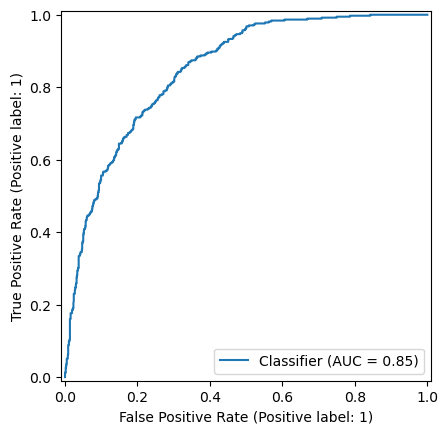

In [67]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_prob)

In [68]:
import pandas as pd

pd.Series(y_pred).value_counts()

0    1078
1     331
Name: count, dtype: int64

In [69]:
pd.Series(y_test).value_counts()

Churn Value
0    1035
1     374
Name: count, dtype: int64

In [70]:
manual_pred_05 = (y_prob >= 0.5).astype(int)

(manual_pred_05 == y_pred).all()

True

## Threshold Tuning

Because churn is an imbalanced target, the decision threshold is compared at multiple cutoffs to show the trade-off between precision and recall for the positive class.

In [71]:
y_pred_04 = (y_prob >= 0.4).astype(int)
pd.Series(y_pred_04).value_counts()

0    974
1    435
Name: count, dtype: int64

In [72]:
print(classification_report(y_test, y_pred_04))

              precision    recall  f1-score   support

           0       0.87      0.82      0.85      1035
           1       0.58      0.67      0.62       374

    accuracy                           0.78      1409
   macro avg       0.73      0.75      0.74      1409
weighted avg       0.80      0.78      0.79      1409



In [73]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.64      0.57      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



In [74]:
confusion_matrix(y_test, y_pred_04)

array([[852, 183],
       [122, 252]])

In [75]:
confusion_matrix(y_test, y_pred)

array([[917, 118],
       [161, 213]])

In [76]:
y_pred_03 = (y_prob >= 0.3).astype(int)
print(classification_report(y_test, y_pred_03))

              precision    recall  f1-score   support

           0       0.89      0.76      0.82      1035
           1       0.53      0.75      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.76      0.77      1409



In [77]:
threshold_results = pd.DataFrame({
    "threshold": [0.5, 0.4, 0.3],
    "predicted_churns": [
        (y_prob >= 0.5).sum(),
        (y_prob >= 0.4).sum(),
        (y_prob >= 0.3).sum()
    ]
})

threshold_results

,threshold,predicted_churns
0,0.5,331
1,0.4,435
2,0.3,524


In [78]:
from sklearn.metrics import precision_score, recall_score, f1_score

threshold_results["precision_class_1"] = [
    precision_score(y_test, (y_prob >= 0.5).astype(int)),
    precision_score(y_test, (y_prob >= 0.4).astype(int)),
    precision_score(y_test, (y_prob >= 0.3).astype(int))
]

threshold_results["recall_class_1"] = [
    recall_score(y_test, (y_prob >= 0.5).astype(int)),
    recall_score(y_test, (y_prob >= 0.4).astype(int)),
    recall_score(y_test, (y_prob >= 0.3).astype(int))
]

threshold_results["f1_class_1"] = [
    f1_score(y_test, (y_prob >= 0.5).astype(int)),
    f1_score(y_test, (y_prob >= 0.4).astype(int)),
    f1_score(y_test, (y_prob >= 0.3).astype(int))
]

threshold_results

,threshold,predicted_churns,precision_class_1,recall_class_1,f1_class_1
0,0.5,331,0.643505,0.569519,0.604255
1,0.4,435,0.579310,0.673797,0.622991
2,0.3,524,0.532443,0.745989,0.621381


### Threshold Comparison Summary

- At threshold 0.5, the model is more conservative:
  fewer customers are flagged as churn, precision is higher, but recall is lower.
- At threshold 0.3, the model is more aggressive:
  more customers are flagged as churn, recall is higher, but precision is lower.
- At threshold 0.4, the model gives the best balance among the tested thresholds for class-1 performance in this baseline experiment.

For now, 0.4 looks like a reasonable candidate threshold if the business wants to catch more churners without becoming too aggressive.

In [79]:
final_threshold = 0.4
final_pred = (y_prob >= final_threshold).astype(int)

In [80]:
print(classification_report(y_test, final_pred))
confusion_matrix(y_test, final_pred)

              precision    recall  f1-score   support

           0       0.87      0.82      0.85      1035
           1       0.58      0.67      0.62       374

    accuracy                           0.78      1409
   macro avg       0.73      0.75      0.74      1409
weighted avg       0.80      0.78      0.79      1409



array([[852, 183],
       [122, 252]])

## Coefficient Inspection

Since the baseline model is linear, the learned coefficients provide a quick directional view of which encoded features push predictions toward or away from churn.

In [81]:
import numpy as np

In [82]:
feature_names = clf.named_steps["preprocessor"].get_feature_names_out()

coefficients = clf.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
}).sort_values(by="coefficient", ascending=False)

coef_df.head(10), coef_df.tail(10)

(                                 feature  coefficient
 6                     cat__Dependents_No     0.645479
 34          cat__Contract_Month-to-month     0.563585
 14     cat__Internet Service_Fiber optic     0.550165
 45                    num__Total Charges     0.521700
 41  cat__Payment Method_Electronic check     0.188563
 30                 cat__Streaming TV_Yes     0.168955
 33             cat__Streaming Movies_Yes     0.155942
 16               cat__Online Security_No     0.132466
 25                  cat__Tech Support_No     0.114846
 12               cat__Multiple Lines_Yes     0.081648,
                                        feature  coefficient
 26       cat__Tech Support_No internet service    -0.285275
 23  cat__Device Protection_No internet service    -0.285275
 10                      cat__Multiple Lines_No    -0.299459
 4                              cat__Partner_No    -0.317788
 37                   cat__Paperless Billing_No    -0.350410
 44                        n

Baseline logistic regression interpretation:

Main churn-associated signals in this baseline:
- Month-to-month contract is strongly associated with higher churn.
- Fiber optic internet is associated with higher churn in this dataset.
- Customers without dependents are more churn-prone.
- Electronic check payment method is associated with higher churn.
- Customers without online security or tech support are more churn-prone.

Main retention-associated signals in this baseline:
- Longer tenure is strongly associated with lower churn.
- Two-year contracts are strongly associated with lower churn.
- Customers with dependents are less likely to churn.

Important note:
These coefficients show association in the baseline logistic regression model, not guaranteed causal effects.

In [83]:
top_churn_drivers = coef_df.head(10).copy()
top_retention_drivers = coef_df.tail(10).sort_values("coefficient").copy()

top_churn_drivers, top_retention_drivers

(                                 feature  coefficient
 6                     cat__Dependents_No     0.645479
 34          cat__Contract_Month-to-month     0.563585
 14     cat__Internet Service_Fiber optic     0.550165
 45                    num__Total Charges     0.521700
 41  cat__Payment Method_Electronic check     0.188563
 30                 cat__Streaming TV_Yes     0.168955
 33             cat__Streaming Movies_Yes     0.155942
 16               cat__Online Security_No     0.132466
 25                  cat__Tech Support_No     0.114846
 12               cat__Multiple Lines_Yes     0.081648,
                                        feature  coefficient
 43                          num__Tenure Months    -1.270244
 7                          cat__Dependents_Yes    -0.989424
 36                      cat__Contract_Two year    -0.734672
 13                   cat__Internet Service_DSL    -0.608835
 44                        num__Monthly Charges    -0.497754
 37                   cat__P